## 1. 逻辑回归与感知机对比

| 对比维度 | 感知机 | 逻辑回归 |
| :--- | :--- | :--- |
| 输出 | 硬分类标签 (+1 / -1) | 概率 (0~1) |
| 损失函数 | 误分类点驱动（不可导） | 交叉熵损失（处处可导、凸函数） |
| 对噪声的容忍度 | 极差，线性不可分就震荡 | 好，输出概率，能衡量“置信度” |
| 解的确定性 | 不唯一 | 唯一（凸优化，全局最优解） |

一句话核心：逻辑回归 = 线性回归 + Sigmoid函数 + 交叉熵损失。

## 2. 生成数据（带 10% 噪声）

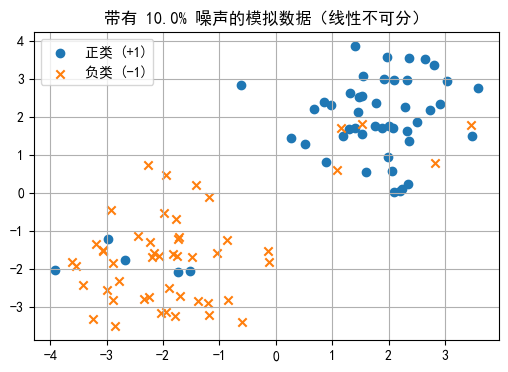

In [7]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题

# 设置随机种子
np.random.seed(42)

# --- 生成线性可分的两类数据（但加上噪声）---
# 类别 +1
X1 = np.random.randn(50, 2) + np.array([2, 2])
y1 = np.ones(50)
# 类别 -1
X2 = np.random.randn(50, 2) + np.array([-2, -2])
y2 = -np.ones(50)

X = np.vstack([X1, X2])
y = np.hstack([y1, y2])

# 引入 10% 标签噪声（让感知机难以收敛）
noise_ratio = 0.1
n_samples = len(y)
n_noise = int(noise_ratio * n_samples)
noise_idx = np.random.choice(n_samples, n_noise, replace=False)
y[noise_idx] = -y[noise_idx]  # 翻转标签

# 可视化
plt.figure(figsize=(6, 4))
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='正类 (+1)', marker='o')
plt.scatter(X[y==-1][:, 0], X[y==-1][:, 1], label='负类 (-1)', marker='x')
plt.title(f'带有 {noise_ratio*100}% 噪声的模拟数据（线性不可分）')
plt.legend()
plt.grid(True)
plt.show()

## 3. 核心数学公式回顾

> 逻辑回归的核心思想：用线性模型的输出经过 **Sigmoid 函数**映射到概率空间，再用 **交叉熵损失** 衡量预测与真实标签的差异，最后通过梯度下降优化参数。

为了推导方便，我们约定标签 $y \in \{0, 1\}$（而不是感知机用的 +1/−1）。如果数据中原本是 -1，可以简单地将其转换为 0。

---

### 1. 线性组合
$$
z = w \cdot x + b
$$
- 这是模型对输入特征 $x$ 的**加权求和**，与感知机完全一致。
- $w$ 是权重向量，$b$ 是偏置（截距）。
- 这个 $z$ 的取值范围是 $(-\infty, +\infty)$，无法直接作为概率。

---

### 2. Sigmoid 函数（压缩概率）
$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$
- **作用**：将线性组合 $z$ 压缩到 $(0, 1)$ 之间，从而可以解释为“样本属于正类（标签为 1）的概率”。
- 当 $z \to +\infty$ 时，$\hat{y} \to 1$；当 $z \to -\infty$ 时，$\hat{y} \to 0$。
- 关键性质：$\sigma(z)$ 处处可导，且导数简洁：$\sigma'(z) = \sigma(z) \cdot (1 - \sigma(z))$，这给梯度计算带来极大便利。

> 这里 $\hat{y}$ 是模型预测的概率，而真实标签 $y$ 是 0 或 1。

---

### 3. 交叉熵损失（单个样本）
$$
L = - \big[\, y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \,\big]
$$
- 这是逻辑回归的**损失函数**，用于衡量预测概率 $\hat{y}$ 与真实标签 $y$ 的差异。
- **直观理解**：
  - 当 $y = 1$ 时，损失变为 $-\log(\hat{y})$。若预测概率接近 1，损失很小；若接近 0，损失趋于无穷大（惩罚极大）。
  - 当 $y = 0$ 时，损失变为 $-\log(1 - \hat{y})$。若预测概率接近 0，损失很小；若接近 1，损失极大。
- 这个损失函数是**凸函数**，没有局部极小值，因此通过梯度下降可以找到全局最优解（与感知机不同，感知机损失不是凸的）。

> 交叉熵源于信息论，鼓励模型对正确类别给出高概率。

---

### 4. 梯度更新公式
对单个样本求损失 $L$ 关于 $w$ 和 $b$ 的偏导数，得到：
$$
\frac{\partial L}{\partial w} = (\hat{y} - y) \cdot x
$$
$$
\frac{\partial L}{\partial b} = (\hat{y} - y)
$$
- 推导过程利用了 Sigmoid 的导数性质，最终形式极其简洁。
- 因此，参数更新规则（梯度下降）为：
  $$
  w \leftarrow w - \eta \cdot (\hat{y} - y) \cdot x
  $$
  $$
  b \leftarrow b - \eta \cdot (\hat{y} - y)
  $$
  其中 $\eta$ 是学习率。

---

### 🔥 神奇之处：与感知机的对比
- **感知机**：更新规则是 $w \leftarrow w + \eta \cdot y_i \cdot x_i$（误分类时），其中 $y_i \in \{-1, +1\}$，预测是硬判决（±1）。
- **逻辑回归**：更新规则本质上也是 $w \leftarrow w - \eta \cdot (\text{预测} - \text{真实}) \cdot x$，但这里的“预测”是连续概率 $\hat{y}$（0~1 之间），而“真实” $y$ 是 0 或 1。

> 两者形式相似：都是 **（预测 - 真实）× 特征** 的形式。
> 但逻辑回归的 $(\hat{y} - y)$ 是**平滑的误差信号**，即使预测接近真实值，更新量也会变小，因此训练过程稳定、收敛平滑；而感知机只要分错就进行固定步长的更新，对噪声敏感且容易震荡。

这就是为什么逻辑回归通常比感知机更实用——它不仅能给出概率，而且优化过程更友好、解具有唯一性。

## 4. 从零实现逻辑回归（封装成类）

In [8]:
class LogisticRegression:
    """使用梯度下降的逻辑回归（二分类）"""

    def __init__(self, learning_rate=0.1, max_epochs=1000, tol=1e-6):
        self.lr = learning_rate
        self.max_epochs = max_epochs
        self.tol = tol  # 早停阈值（损失变化极小就停止）

        self.w = None
        self.b = None
        self.loss_history = []  # 记录损失变化

    def _sigmoid(self, z):
        """防止溢出的小技巧：裁剪输入值"""
        z = np.clip(z, -500, 500)  # 防止 exp 溢出
        return 1 / (1 + np.exp(-z))

    def _loss(self, X, y):
        """计算当前参数下的平均交叉熵损失"""
        m = X.shape[0]
        z = np.dot(X, self.w) + self.b
        y_pred = self._sigmoid(z)
        # 防止 log(0) 出现 nan
        eps = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = - (1/m) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return loss

    def fit(self, X, y):
        """
        X: shape (m, n)
        y: 取值 0 或 1 (注意：传入前需要把 -1 转为 0)
        """
        m, n = X.shape

        # 1. 初始化参数为 0
        self.w = np.zeros(n)
        self.b = 0.0
        self.loss_history = []

        # 2. 梯度下降迭代
        for epoch in range(self.max_epochs):
            # --- 前向传播 ---
            z = np.dot(X, self.w) + self.b
            y_pred = self._sigmoid(z)

            # --- 计算损失 ---
            loss = self._loss(X, y)
            self.loss_history.append(loss)

            # --- 反向传播（计算梯度）---
            # 梯度公式：dw = (1/m) * X.T * (y_pred - y)
            dz = y_pred - y
            dw = (1/m) * np.dot(X.T, dz)
            db = (1/m) * np.sum(dz)

            # --- 更新参数 ---
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # --- 早停机制：如果损失变化极小，提前终止 ---
            if epoch > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                print(f"在第 {epoch+1} 轮收敛（损失变化小于 {self.tol}）")
                break

        print(f"训练完成，共迭代 {len(self.loss_history)} 轮，最终损失: {self.loss_history[-1]:.6f}")

    def predict_proba(self, X):
        """预测属于类别 1 的概率"""
        z = np.dot(X, self.w) + self.b
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        """预测类别 0 或 1"""
        prob = self.predict_proba(X)
        return (prob >= threshold).astype(int)

    def score(self, X, y):
        """计算准确率"""
        pred = self.predict(X)
        return np.mean(pred == y)

## 5. 数据预处理与训练
#### 注意：逻辑回归期望标签为 0 和 1，我们需要把当前的 +1 / -1 映射过去

In [9]:
# 将标签转为 0 和 1
y_logistic = np.where(y == 1, 1, 0)

# 创建模型实例
model = LogisticRegression(learning_rate=0.1, max_epochs=1000)

# 训练模型
model.fit(X, y_logistic)

# 查看准确率
acc = model.score(X, y_logistic)
print(f"训练集准确率: {acc * 100:.2f}%")

在第 244 轮收敛（损失变化小于 1e-06）
训练完成，共迭代 244 轮，最终损失: 0.346772
训练集准确率: 90.00%


## 6. 绘制损失下降曲线

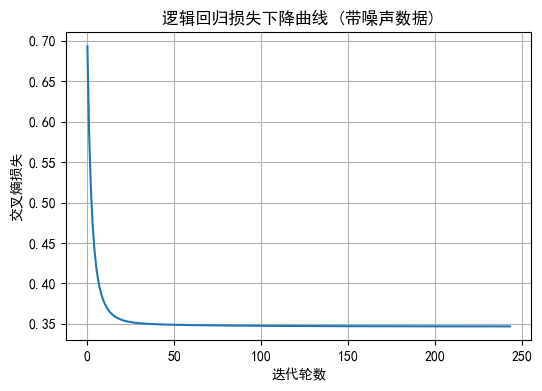

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(range(len(model.loss_history)), model.loss_history)
plt.xlabel('迭代轮数')
plt.ylabel('交叉熵损失')
plt.title('逻辑回归损失下降曲线 (带噪声数据)')
plt.grid(True)
plt.show()

## 7. 可视化决策边界（概率等高线）
#### 逻辑回归输出的是概率，我们可以画出 P(y=1) = 0.5 的决策面，以及 0.3 / 0.7 的置信度边界。

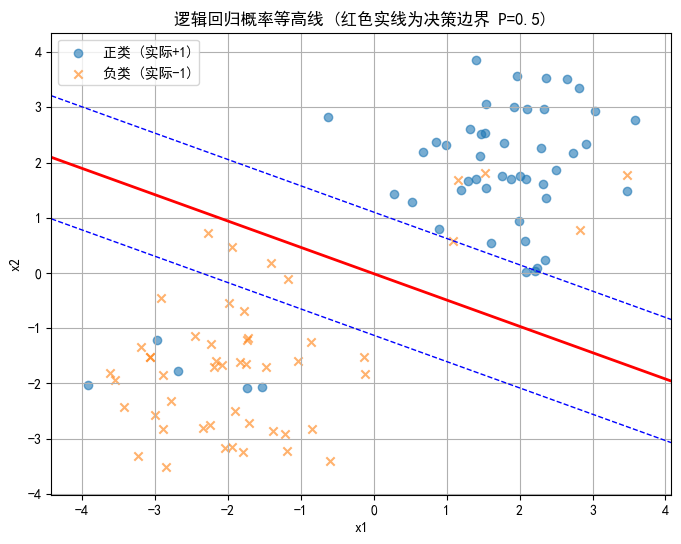

In [11]:
# 绘制散点
plt.figure(figsize=(8, 6))
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='正类 (实际+1)', marker='o', alpha=0.6)
plt.scatter(X[y==-1][:, 0], X[y==-1][:, 1], label='负类 (实际-1)', marker='x', alpha=0.6)

# 生成网格数据
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# 预测网格点的概率
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict_proba(grid_points).reshape(xx.shape)

# 绘制等高线
# 画 0.5 决策边界（白色粗线），0.3 和 0.7 为细虚线
plt.contour(xx, yy, Z, levels=[0.3, 0.5, 0.7],
            colors=['blue', 'red', 'blue'], linestyles=['--', '-', '--'], linewidths=[1, 2, 1])

plt.title('逻辑回归概率等高线 (红色实线为决策边界 P=0.5)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

## 8. Sklearn 的实现

In [12]:
from sklearn.linear_model import LogisticRegression as SklearnLR

sk_model = SklearnLR(C=1.0)  # C 是正则化强度的倒数，这里默认
sk_model.fit(X, y_logistic)
print(f"Sklearn 准确率: {sk_model.score(X, y_logistic):.2f}")

Sklearn 准确率: 0.90
